<a href="https://colab.research.google.com/github/gibranfp/CursoAprendizajeProfundo/blob/2026-1/notebooks/4b_vit_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de rostros por grupo etario con ViT

**Índice**   
1. [Importación de paqueterías](#id1)
2. [Carga de conjuntos de datos](#id2)
3. [Definición de función](#id3)
4. [Entrenamiento con ViT](#id4)
5. [Bloque Transformer](#id5)
6 .[](#)

## 1. Importación de paqueterías<a name="id1"></a>

In [ ]:
import copy
from math import sqrt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zipfile
import torch as th
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as T
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Dataset
from FairFaceDatasetZip import FairFaceDatasetZip
import PIL
import os

import torchvision as tv
import torchvision.transforms as T


from tqdm.auto import trange
from einops import rearrange

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

ROWS, COLS = 4, 8
N_EPOCAS = 30
T_LOTE = 64
T_IMG = (32, 32)
NUM_WORKERS = 4
N_IMGS_MUESTRA = 36

T_PARCHES = 8       # tamaño de los parches
D_EMBED = 128       # tamaño de los embeddings
N_CABEZAS = 8       # numero de cabezas de autoatención
N_CAPAS = 6         # numero de bloques Transformers
RDP_DIM = 512       # tamaño de salidas de red hacia adelante por posición
P_DROPOUT = 0.2

LOGDIR = './runs/'
DISP = 'cuda:0' if th.cuda.is_available() else 'cpu'

np.random.seed(42)
th.random.manual_seed(42)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga de conjuntos de datos<a name="id2"></a>
Se cargan las imágenes del conjunto de datos [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html).  proporcionado por [`torchvision`](https://docs.pyth.org/vision).

In [ ]:
trn_tr = T.Compose([T.RandomResizedCrop(T_IMG,
                                        scale = (0.85, 1.0),
                                        ratio = (1.0, 1.0)),
                    T.RandomVerticalFlip(),
                    T.RandomHorizontalFlip(),
                    T.ToTensor(),
                    T.Normalize(mean = IMAGENET_MEAN,
                                std = IMAGENET_STD)])

val_tr = T.Compose([T.Resize(T_IMG),
                    T.ToTensor(),
                    T.Normalize(mean = IMAGENET_MEAN,
                                std = IMAGENET_STD)])

In [ ]:
data=pd.read_csv("fairface_label_train.csv")

print(data["age"].unique())

orden = ['0-2', '3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', 'more than 70']
NUM_CLASSES=len(orden)

mapa_edad = {v: i for i, v in enumerate(orden)} 

data["age_CG"] = data["age"].map(mapa_edad)
print(data)
ind_ent, ind_val = train_test_split(data, test_size=0.2, random_state=42, stratify=data["age_CG"])


['50-59' '30-39' '3-9' '20-29' '40-49' '10-19' '60-69' '0-2'
 'more than 70']
                  file           age  gender        race  service_test  age_CG
0          train/1.jpg         50-59    Male  East Asian          True       6
1          train/2.jpg         30-39  Female      Indian         False       4
2          train/3.jpg           3-9  Female       Black         False       1
3          train/4.jpg         20-29  Female      Indian          True       3
4          train/5.jpg         20-29  Female      Indian          True       3
...                ...           ...     ...         ...           ...     ...
86739  train/86740.jpg         20-29    Male      Indian          True       3
86740  train/86741.jpg         10-19    Male      Indian          True       2
86741  train/86742.jpg  more than 70  Female      Indian          True       8
86742  train/86743.jpg         10-19  Female       Black          True       2
86743  train/86744.jpg         40-49    Male       Wh

## 3. Definición de función<a name="id3"></a>

In [ ]:
zip_path='/Usuario/Pablo/Desktop/DL'
train_dataset = FairFaceDatasetZip(ind_ent, zip_path,transform=trn_tr) 
ds_prueba = FairFaceDatasetZip(ind_val, zip_path,transform=trn_tr)
it_ent = iter(train_dataset)
img_ent, cat_ent = next(it_ent)

print(data["age_CG"].unique())


[6 4 1 3 5 2 7 0 8]


In [6]:
ent_dl = th.utils.data.DataLoader(train_dataset,
                                  batch_size = T_LOTE,
                                  shuffle = True,
                                  num_workers = NUM_WORKERS)

val_dl = th.utils.data.DataLoader(ds_prueba,
                                  batch_size = T_LOTE,
                                  shuffle = False,
                                  num_workers = NUM_WORKERS)

## 4. Entrenamiento con ViT<a name="id4"></a>

La arquitectura Vision Transformer, basada en bloques Transformer, es propuesta en el artículo [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://arxiv.org/abs/2010.11929).

La función de puntaje del `producto punto` entre el $i$-ésimo vector de consulta $\mathbf{q}^{[i]}\in \mathbb{R}^{d_k}$ y el $j$-ésimo vector de llave $\mathbf{k}^{[j]} \in \mathbb{R}^{d_k}$ está definida como:
$$
\text{puntaje}(\mathbf{q}^{[i]}, \mathbf{k}^{[j]}) = \frac{\mathbf{q}^{[i] \top} \mathbf{k}^{[j]}}{\sqrt{d_k}},
$$

donde $i,j \in [1, \ldots, T]$. Su valor de atención $\alpha_{i,j}$ está dado por:
$$
\alpha_{i,j} = \text{softmax}\left(\text{puntaje}(\mathbf{q}^{[i]}, \mathbf{k}^{[j]})\right)
$$

In [ ]:
class ProductoPunto(nn.Module):
  def __init__(self):
    super(ProductoPunto, self).__init__()

  def forward(self, Q, K, V):
    m, n_cabezas, l, d_k = K.shape
    d_v = V.shape[-1]

    Q = Q.reshape(m * n_cabezas, l, d_k)
    K = K.reshape(m * n_cabezas, l, d_k)
    V = V.reshape(m * n_cabezas, l, d_v)

    QK = th.bmm(Q, K.transpose(1, 2))
    QK_esc = QK / th.math.sqrt(d_k)

    alfas = nn.functional.softmax(QK_esc, dim = -1)

    Y = th.bmm(alfas, V)
    Y = Y.reshape(m, n_cabezas, l, d_v)

    alfas = alfas.reshape(m, n_cabezas, l, l)

    return Y, alfas

ppe = ProductoPunto()
ppe(th.rand([1, 4, 10, 64]), # Q
    th.rand([1, 4, 10, 64]), # K
    th.rand([1, 4, 10, 64]))[0].shape # V

torch.Size([1, 4, 10, 64])

En la autoatención de la arquitectura Transformer, cada vector $\mathbf{x}^{[i]} \in \mathbb{R}^{d_{modelo} \times 1}$ en la secuencia se transforma a tres usando las matrices entrenables $\mathbf{W}_q \in \mathbb{R}^{d_k \times d_{modelo}}$, $\mathbf{W}_k \in \mathbb{R}^{d_k \times d_{modelo}}$ y $\mathbf{W}_v \in \mathbb{R}^{d_v \times d_{modelo}}$: uno conocido como consulta $\mathbf{q}^{[i]} \in \mathbb{R}^{d_k \times 1}$, otro como llave $\mathbf{k}^{[i]} \in \mathbb{R}^{d_k \times 1}$ y un tercero como valor $\mathbf{v}^{[i]} \in \mathbb{R}^{d_k \times 1}$:

\begin{align*}
\mathbf{q}^{[i]} & = \mathbf{W}_q \mathbf{x}^{[i]}\\
\mathbf{k}^{[i]} & =  \mathbf{W}_k \mathbf{x}^{[i]}\\
\mathbf{v}^{[i]} & = \mathbf{W}_v \mathbf{x}^{[i]}
\end{align*}

El $i$-ésimo vector de salida $\mathbf{a}^{[i]} \in \mathbb{R}^{d_v \times 1}$ en la secuencia se obtiene calculando la suma de cada vector de valor $\mathbf{v}^{[j]}$ ponderado por su valor de atención $\alpha_{i,j}$:
$$
\mathbf{a}^{[i]} = \sum_{j=1}^T \alpha_{i,j}\cdot \mathbf{v}^{[j]}
$$

Para llevar a cabo la `atención multicabeza`, esta operación se lleva a cabo con $h$ matrices entrenables distintas y se concatenan los $h$ vectores de salida resultantes de la $i$-ésima posición en un vector solo vector $\mathbf{o}^{[i]} \in \mathbb{R}^{(h \cdot d_v) \times 1}$:
$$
\mathbf{o}^{[i]} = [\mathbf{a}^{[i]}_1;\cdots;\mathbf{a}^{[i]}_h]
$$

Este vector se multiplica por la matriz entrenable $\mathbf{W}_o \in \mathbb{R}^{d_{modelo} \times (h \cdot d_v)}$ para producir el vector de salida $\mathbf{y}^{[i]}  \in \mathbb{R}^{d_{modelo} \times 1}$ de la autoatención multicabeza:

$$
\mathbf{y}^{[i]} = \mathbf{W}_o \cdot \mathbf{o}^{[i]}
$$

In [ ]:
class AtencionMulticabeza(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas):
    super(AtencionMulticabeza, self).__init__()

    self.n_cabezas = n_cabezas
    self.d_modelo = d_modelo
    self.d_k = self.d_modelo // self.n_cabezas

    self.ppe = ProductoPunto()

    self.proy_Q = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_K = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_V = nn.Linear(self.d_modelo, self.d_modelo, bias = False)

    self.proy_sal = nn.Linear(self.d_modelo, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    Q = self.proy_Q(x)
    K = self.proy_K(x)
    V = self.proy_V(x)

    Q = Q.reshape(m, l, self.n_cabezas, self.d_k)
    K = K.reshape(m, l, self.n_cabezas, self.d_k)
    V = V.reshape(m, l, self.n_cabezas, self.d_k)

    Q = Q.transpose(1, 2).contiguous()
    K = K.transpose(1, 2).contiguous()
    V = V.transpose(1, 2).contiguous()

    Y, alfas = self.ppe(Q, K, V)
    Y = Y.transpose(1, 2).contiguous()
    Y = Y.reshape(m, l, self.d_modelo)
    Y = self.proy_sal(Y)

    return Y, alfas

amc = AtencionMulticabeza(256, 2)
amc(th.rand([1, 10, 256]))[0].shape

torch.Size([1, 10, 256])

Cada vector de la secuencia de salida de la autoatención multicabeza se procesa mediante una `red hacia adelante por posición`, compuesta por 2 capas densas:

$$
\hat{\mathbf{y}}^{[i]} = \max(0, \mathbf{y}^{[i]} \cdot \mathbf{W}^{\{1\}} + b^{\{1\}}) \cdot \mathbf{W}^{\{2\}} + b^{\{2\}}
$$

donde $\mathbf{y}^{[i]}$ es el $i$-ésimo vector en la secuencia.

In [ ]:
class RedDensaPosicion(nn.Module):
  def __init__(self,
               d_modelo,
               d_rdp,
               p_dropout):
    super(RedDensaPosicion, self).__init__()

    self.d_modelo = d_modelo
    self.d_rdp = d_rdp

    self.densa1 = nn.Linear(self.d_modelo, self.d_rdp)
    self.densa2 = nn.Linear(self.d_rdp, self.d_modelo)

    self.dropout1 = nn.Dropout(p_dropout)
    self.dropout2 = nn.Dropout(p_dropout)

  def forward(self, x):
    m, l, d_modelo = x.shape
    x = self.densa1(x)
    x = nn.functional.gelu(x)
    x = self.dropout1(x)
    x = self.densa2(x)
    x = self.dropout2(x)

    return x

rdp = RedDensaPosicion(256, 512, 0.2)
rdp(th.rand([1, 10, 256]))

tensor([[[ 0.2871,  0.2819, -0.0088,  ...,  0.0094, -0.0945,  0.0000],
         [ 0.1358,  0.1480, -0.0935,  ...,  0.0087, -0.0000,  0.0772],
         [ 0.0727,  0.3452,  0.1764,  ...,  0.0087, -0.2144,  0.0340],
         ...,
         [ 0.0763,  0.0000,  0.0176,  ..., -0.0000, -0.0019, -0.0492],
         [ 0.1310,  0.0000,  0.1546,  ..., -0.3620, -0.0000,  0.0600],
         [-0.0097,  0.0000, -0.0475,  ..., -0.0392, -0.1735,  0.0941]]],
       grad_fn=<MulBackward0>)

## 5. Bloque Transformer<a name="id5"></a>
Definimos el bloque Transformer, el cual está compuesto por una normalización por capas,
una atención multicabeza y una conexión residual, seguida por otra normalización por capas, una red hacia adelante por posición y otra conexión residual. Nota que a diferencia del bloque de Transformer original, la normalización por capas se realiza a la entrada en lugar de a la salida de las conexiones residuales.

<img src="https://theaisummer.com/static/aa65d942973255da238052d8cdfa4fcd/7d4ec/the-transformer-block-vit.png">

Imagen tomada de https://arxiv.org/abs/2010.11929.

In [10]:
class BloqueTransformer(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               d_rdp,
               p_dropout = 0.0):
    super(BloqueTransformer, self).__init__()

    self.amc = AtencionMulticabeza(d_modelo = d_modelo,
                                   n_cabezas = n_cabezas)
    self.norm1 = nn.LayerNorm(d_modelo)
    self.norm2 = nn.LayerNorm(d_modelo)

    self.dropout1 = nn.Dropout(p_dropout)

    self.mlp = RedDensaPosicion(d_modelo, d_rdp, p_dropout)

  def forward(self, x):
    x_ln1 = self.norm1(x)
    salidas_amc, alfas = self.amc(x_ln1)
    salidas_amc = self.dropout1(salidas_amc)

    x = salidas_amc + x
    x_ln2 = self.norm2(x)
    mlp = self.mlp(x_ln2)
    out = mlp + x

    return out

bt = BloqueTransformer(256, 4, 512, 0.2)
bt(th.rand([1, 10, 256])).shape

torch.Size([1, 10, 256])

## 6. ViT
La arquitectura ViT, la cual está compuesta por varios bloques Transformer. Como entrada recibe una imagen $\mathbf{I^{(i)}}$ de tamaño $H\times W \times C$ y la divide en $B$ partes $\mathbf{x}_k^{(i)}, k = 1, \ldots, B$ de tamaño $P \times P \times C)$, donde $B = \frac{H\cdot W}{P^2}$.

Cada parche se aplana y se proyecta con una capa densa, obteniendo como resultado un vector de $d$ dimensiones. Los vectores asociados a los parches de la imagen se procesan como una secuencia, al inicio de la cual se agrega un vector entrenable llamado CLS. A la secuencia completa se le suma un vector de codificación posicional entrenable y posteriormente se pasa por varios bloques Transformer. El vector correspondiente a CLS en la secuencia de salida del último bloque Transformer se pasa por una capa densa con función softmax que sirve como clasificador.

<img src="https://upload.wikimedia.org/wikipedia/commons/9/93/Vision_Transformer.png">

Imagen tomada de [https://en.wikipedia.org/wiki/Vision_transformer](https://en.wikipedia.org/wiki/Vision_transformer).

In [ ]:
class ViT(nn.Module):
  def __init__(self,
               img_size,
               t_parches,
               n_clases,
               d_embed,
               n_capas,
               n_cabezas,
               rdp_dim,
               p_dropout):
    super().__init__()

    self.d_embed = d_embed
    self.n_clases = n_clases
    self.t_parches = t_parches

    self.n_parches = (img_size // t_parches) ** 2

    input_projection = (t_parches * t_parches * 3) 
    self.projection = nn.Linear(input_projection, d_embed)

    self.pos_embedding = nn.Parameter(th.randn(1,
                                               self.n_parches + 1, d_embed))

   
    self.cls_token = nn.Parameter(th.randn(1, 1, d_embed))
    bloques = [BloqueTransformer(d_embed,
                                 n_cabezas,
                                 rdp_dim,
                                 p_dropout) for _ in range(n_capas)]
    self.transformer = nn.Sequential(*bloques)

    self.classifier = nn.Sequential(nn.LayerNorm(d_embed),
                                    nn.Linear(d_embed, n_clases))

  def forward(self, x):
    m = x.shape[0]
    parches = rearrange(x,
                        'm c (patch_x x) (patch_y y) -> m (x y) (patch_x patch_y c)',
                        patch_x = self.t_parches, patch_y = self.t_parches)

    x = self.projection(parches)
    cls_token = self.cls_token.repeat(m, 1, 1)
    x = th.cat((cls_token, x), dim = 1)
    x += self.pos_embedding
    x = self.transformer(x)

    x = x[:, 0, :]
    x = self.classifier(x)

    return x

modelo = ViT(T_IMG[0],
             t_parches = T_PARCHES,
             n_clases = len(orden),
             d_embed = D_EMBED,
             n_capas = N_CAPAS,
             n_cabezas = N_CABEZAS,
             rdp_dim = RDP_DIM,
             p_dropout = P_DROPOUT)
modelo(th.rand(1, 3, T_IMG[0], T_IMG[1])).shape

torch.Size([1, 9])

Calculámos el número de parámetros del modelo.

In [12]:
n_params = sum(p.numel() for p in modelo.parameters())
print(f'{n_params} parámetros')

1215753 parámetros


## 7. Funciones para el entrenamiento
Para facilitar el entrenamiento, definimos diversas funciones.

### Guardar _checkpoint_
Podemos guardar el estado del entrenamiento y de un modelo mediante la función `save`.

In [13]:
def guarda_ckpt(ckptpath, modelo, epoca, opt):
  estado_modelo = {'epoch': epoca,
                   'model_state_dict': modelo.state_dict(),
                   'optimizer_state_dict': opt.state_dict()}
  th.save(estado_modelo, ckptpath)

### Registrar información para Tensorboard
Para guardar información que pueda visualizarse con Tensorboard, instanciamos la clase `SummaryWriter` del submódulo `tensorboard` del módulo `utils` y escribimos información mediante los distintos métodos disponibles (por ej. `add_scalar`, `add_image`, `add_histogram`, etc.).

In [14]:
def registra_info_tboard(writer, epoca, hist):
  for (m,v) in hist.items():
    writer.add_scalar(m, v[epoca], epoca)

### Métrica de exactitud
Definimos una función para calcular la exactitud:

$$
exactitud = \frac{\#correctos}{\#total}
$$

In [15]:
def exactitud(y_hat, y):
  cmp = y_hat.argmax(axis = -1) == y
  aciertos = cmp.sum()
  return aciertos / cmp.shape[0]

## 8. Paso de entrenamiento
Definimos una función que realiza un paso de entrenamiento, a la cual llamaremos `paso_ent`. Esta función recibe como argumentos:
- El modelo como una instancia de `Module` (`modelo`).
- La función de pérdida (`fp`).
- La métrica a evaluar (`metrica`)
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos (`opt`).
- Una instancia de `Tensor` con el lote de entradas (`X`).
- Una instancia de `Tensor` con el lote de salidas (`y`).

La función obtiene las predicciones del modelo para las entradas, calcula la pérdida, obtiene los gradientes y actualiza todos los parámetros del modelo mediante el optimizador pasado como argumento.

In [16]:
def paso_ent(modelo,
             fp,
             metrica,
             opt,
             X,
             y):
  opt.zero_grad() # se ponen los gradientes asociados a los parámetros
                    # a actualizaren en cero
  y_hat = modelo(X) # se propagan las entradas para obtener las predicciones
  perdida = fp(y_hat, y) # se calcula la pérdida
  perdida.backward() # se obtienen los gradientes
  opt.step() # se actualizan todos los parámetros del modelo

  with th.no_grad():
    perdida_paso = perdida.cpu().numpy() # convertimos la pérdida (instancia de
                                         # Tensor de orden 0) a NumPy, para
                                         # lo que es necesario moverla a CPU
    metricas_paso = metrica(y_hat, y)

  return perdida_paso, metricas_paso

También definimos el ciclo de entrenamiento principal, que llamaremos `entrena`. Esta función recibe como argumentos:
- El modelo como una instancia de `Module` (`modelo`).
- La función de pérdida (`fp`).
- La métrica a evaluar (`metrica`)
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos (`opt`).
- El cargador de datos del subconjunto de entrenamiento (`entdl`).
- El cargador de datos del subconjunto de validación (`valdl`).
- El dispositivo en el que se ejecutará el modelo (`disp`).
- La ruta al archivo donde se guardará el estado del entrenamiento y el modelo (`ckptpath`).
- El número de épocas de entrenamiento (`n_epocas`).
- La ruta al directorio donde se guardará la información para Tensorboard (`tbdir`).

Para cada una de las épocas, va tomando un lote de entradas y salidas a la vez, con los cuales se realiza un paso de entrenamiento.

In [17]:
def entrena(modelo,
            fp,
            metrica,
            opt,
            entdl,
            valdl,
            disp,
            ckptpath,
            n_epocas = 10,
            tbdir = 'runs/'):
  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {
    'ent': {
    'perdida': np.zeros(n_epocas),
      metrica.__name__: np.zeros(n_epocas)
      },
    'val': {
    'perdida': np.zeros(n_epocas),
      metrica.__name__: np.zeros(n_epocas)
      }
  }

  tbwriter_ent = SummaryWriter(tbdir + '/ent')
  tbwriter_val = SummaryWriter(tbdir + '/val')

  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in range(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    for Xlote,ylote in entdl:
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)

      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist["ent"]['perdida'][e] += perdida_paso
      hist["ent"][metrica.__name__][e] += metrica_paso

    # bucle de validación
    modelo.eval()
    with th.no_grad():
      for Xlote,ylote in valdl:
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp)

        y_hat = modelo(Xlote)

        hist['val']['perdida'][e] += fp(y_hat, ylote)
        hist['val'][metrica.__name__][e] += metrica(y_hat, ylote)

    hist['ent']['perdida'][e] /=  n_lotes_ent
    hist['ent'][metrica.__name__][e] /= n_lotes_ent
    hist['val']['perdida'][e] /=  n_lotes_val
    hist['val'][metrica.__name__][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['val']['perdida'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)
      perdida_min = hist['val']['perdida'][e]

    registra_info_tboard(tbwriter_ent, e, hist['ent'])
    registra_info_tboard(tbwriter_val, e, hist['val'])

    print(f'Época {e}: '
          f'Perdida(E) = {hist["ent"]["perdida"][e]:.3f}, '
          f'{metrica.__name__}(E) = {hist["ent"][metrica.__name__][e]:.3f}, '
          f'Perdida(V) = {hist["val"]["perdida"][e]:.3f}, '
          f'{metrica.__name__}(V) = {hist["val"][metrica.__name__][e]:.3f}')

  return modelo, mejor_modelo, hist

Instanciamos nuestro modelo, el criterio para la pérdida, el optimizador y llamamos a la función `entrena`.

In [18]:
# pasamos modelo a GPU, si está disponible
modelo = modelo.to(DISP)

perdida = nn.CrossEntropyLoss(weight = None,
                              reduction = 'mean')
opt = th.optim.Adam(modelo.parameters(),
                    lr = 0.0001,
                    weight_decay = 0.0001)

modelo, mejor_modelo, hist = entrena(modelo,
                                     perdida,
                                     exactitud,
                                     opt,
                                     ent_dl,
                                     val_dl,
                                     DISP,
                                     LOGDIR + '/vit.pt',
                                     n_epocas = N_EPOCAS,
                                     tbdir = LOGDIR)

Época 0: Perdida(E) = 1.836, exactitud(E) = 0.293, Perdida(V) = 1.797, exactitud(V) = 0.302
Época 1: Perdida(E) = 1.792, exactitud(E) = 0.304, Perdida(V) = 1.757, exactitud(V) = 0.320
Época 2: Perdida(E) = 1.752, exactitud(E) = 0.319, Perdida(V) = 1.726, exactitud(V) = 0.326
Época 3: Perdida(E) = 1.722, exactitud(E) = 0.328, Perdida(V) = 1.705, exactitud(V) = 0.330
Época 4: Perdida(E) = 1.701, exactitud(E) = 0.335, Perdida(V) = 1.674, exactitud(V) = 0.340
Época 5: Perdida(E) = 1.685, exactitud(E) = 0.342, Perdida(V) = 1.667, exactitud(V) = 0.349
Época 6: Perdida(E) = 1.665, exactitud(E) = 0.348, Perdida(V) = 1.652, exactitud(V) = 0.353
Época 7: Perdida(E) = 1.652, exactitud(E) = 0.353, Perdida(V) = 1.623, exactitud(V) = 0.361
Época 8: Perdida(E) = 1.637, exactitud(E) = 0.359, Perdida(V) = 1.633, exactitud(V) = 0.353
Época 9: Perdida(E) = 1.626, exactitud(E) = 0.363, Perdida(V) = 1.596, exactitud(V) = 0.367
Época 10: Perdida(E) = 1.614, exactitud(E) = 0.367, Perdida(V) = 1.591, exactitu

Graficamos la pérdida y la exactitud.

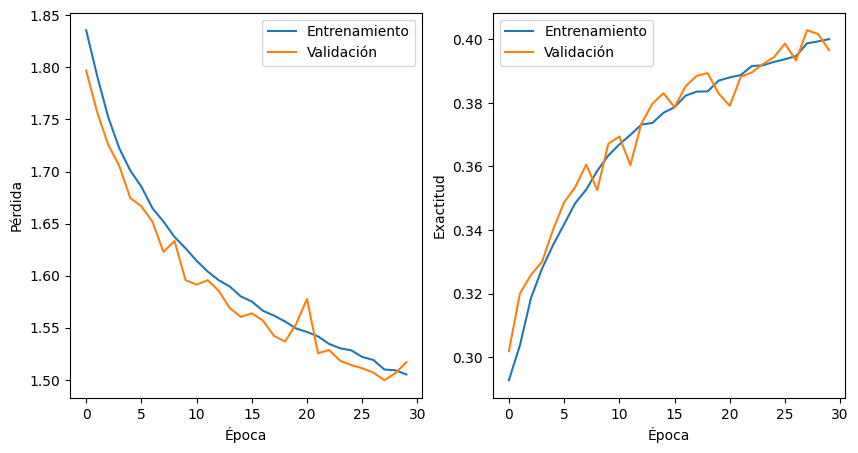

In [19]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(hist['ent']['perdida'], label='Entrenamiento')
axs[0].plot(hist['val']['perdida'], label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(hist['ent']['exactitud'], label='Entrenamiento')
axs[1].plot(hist['val']['exactitud'], label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Exactitud')
axs[1].legend()
plt.show()

## 9. Evaluación
Evaluamos el desempeño del modelo entrenado en el conjunto de validación.

In [28]:
pred_val = np.zeros((len(ds_prueba), NUM_CLASSES))
y_val = np.zeros(len(ds_prueba))
with th.no_grad():
  for i in range(len(ds_prueba)):
    x, y = ds_prueba[i]
    x = x.to(DISP)
    pred_val[i] = mejor_modelo(x.unsqueeze(0)).cpu().numpy()
    y_val[i] = y

print(f'F1 = {f1_score(y_val, pred_val.argmax(axis = 1), average = "macro")}\n'
      f'Exactitud = {exactitud(pred_val, y_val)}\n'
      f'Exhaustividad = {recall_score(y_val, pred_val.argmax(axis = 1), average = "macro")}\n'
      f'Precisión = {precision_score(y_val, pred_val.argmax(axis = 1), average = "macro")}\n'
      f'Matriz de confusión:\n {confusion_matrix(y_val, pred_val.argmax(axis = -1))}')

F1 = 0.28921649601329463
Exactitud = 0.3931062309066805
Exhaustividad = 0.27684041503582896
Precisión = 0.4319335540813923
Matriz de confusión:
 [[ 119  184    2   38   10    4    1    0    0]
 [  37 1220  106  610   55   24   24    5    1]
 [   3  300  126 1199  126   38   29    0    0]
 [   3  223   71 3736  771  196  115    5    0]
 [   4  101   38 2278  874  365  179   11    0]
 [   0   50   18  942  507  360  263    9    0]
 [   1   32    7  376  230  230  335   33    1]
 [   0   13    2  164   88   55  188   45    1]
 [   1   10    2   45   21   15   51   18    5]]


age_CG
3    5120
4    3850
5    2149
1    2082
2    1821
6    1245
7     556
0     358
8     168
Name: count, dtype: int64

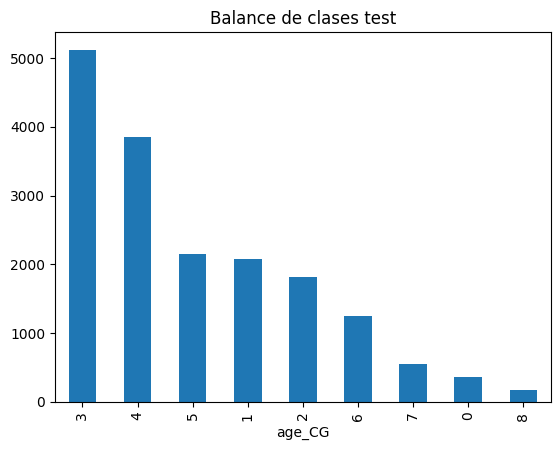

In [34]:
ind_val["age_CG"].value_counts().plot(kind="bar", title="Balance de clases test")

ind_val["age_CG"].value_counts()

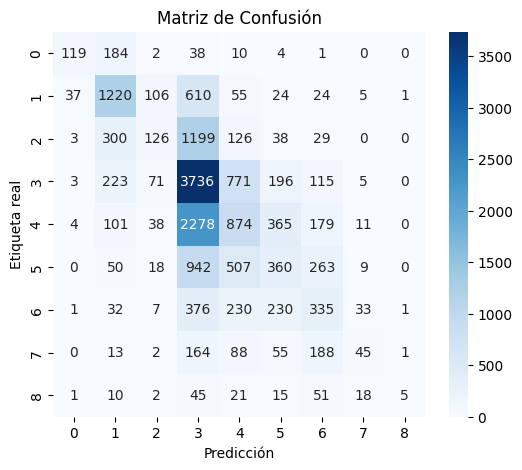

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, pred_val.argmax(axis=1))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión")
plt.show()


## 9. Entrenamiento con ResNet

In [ ]:

class ResNET(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out
    
class ViT_RESNET(nn.Module):
  def __init__(self,
               img_size,
               t_parches,
               n_clases,
               d_embed,
               n_capas,
               n_cabezas,
               rdp_dim,
               p_dropout):
    super().__init__()

    self.d_embed = d_embed
    self.n_clases = n_clases
    self.t_parches = t_parches

  
    self.n_parches = (img_size // t_parches) ** 2


    input_projection = (t_parches * t_parches * 3) # P x P x C
    #self.projection = nn.Linear(input_projection, d_embed)
    
    self.projection = nn.Sequential(
            ResNET(in_channels=3, out_channels=d_embed),  
            nn.Flatten(1),  
            nn.Linear(d_embed * t_parches * t_parches, d_embed)  
        )
    
    # codificación posicional entrenable
    self.pos_embedding = nn.Parameter(th.randn(1,
                                               self.n_parches + 1, d_embed))

    self.cls_token = nn.Parameter(th.randn(1, 1, d_embed))
    bloques = [BloqueTransformer(d_embed,
                                 n_cabezas,
                                 rdp_dim,
                                 p_dropout) for _ in range(n_capas)]
    self.transformer = nn.Sequential(*bloques)


    self.classifier = nn.Sequential(nn.LayerNorm(d_embed),
                                    nn.Linear(d_embed, n_clases))

  def forward(self, x):
 
    m = x.shape[0]
    parches = rearrange(x, 'm c (patch_x x) (patch_y y) -> (m x y) c patch_x patch_y',
                    patch_x=self.t_parches, patch_y=self.t_parches)
    x = self.projection(parches)
    x = x.view(m, -1, self.d_embed)  
    cls_token = self.cls_token.repeat(m, 1, 1)
    x = th.cat((cls_token, x), dim = 1)
    x += self.pos_embedding
    x = self.transformer(x)
    x = x[:, 0, :]

  
    x = self.classifier(x)

    return x

modelo_RES = ViT_RESNET(T_IMG[0],
             t_parches = T_PARCHES,
             n_clases = len(orden),
             d_embed = D_EMBED,
             n_capas = N_CAPAS,
             n_cabezas = N_CABEZAS,
             rdp_dim = RDP_DIM,
             p_dropout = P_DROPOUT)
modelo_RES(th.rand(1, 3, T_IMG[0], T_IMG[1])).shape

torch.Size([1, 9])

In [ ]:
modelo_RES = modelo_RES.to(DISP)

perdida = nn.CrossEntropyLoss(weight = None,
                              reduction = 'mean')
opt = th.optim.Adam(modelo_RES.parameters(),
                    lr = 0.0001,
                    weight_decay = 0.0001)

modelo_RES, mejor_modelo, hist = entrena(modelo_RES,
                                     perdida,
                                     exactitud,
                                     opt,
                                     ent_dl,
                                     val_dl,
                                     DISP,
                                     LOGDIR + '/vit_RESS.pt',
                                     n_epocas = N_EPOCAS,
                                     tbdir = LOGDIR)

Época 0: Perdida(E) = 1.774, exactitud(E) = 0.312, Perdida(V) = 1.675, exactitud(V) = 0.341
Época 1: Perdida(E) = 1.630, exactitud(E) = 0.356, Perdida(V) = 1.581, exactitud(V) = 0.370
Época 2: Perdida(E) = 1.569, exactitud(E) = 0.376, Perdida(V) = 1.591, exactitud(V) = 0.373
Época 3: Perdida(E) = 1.532, exactitud(E) = 0.388, Perdida(V) = 1.509, exactitud(V) = 0.396
Época 4: Perdida(E) = 1.502, exactitud(E) = 0.398, Perdida(V) = 1.470, exactitud(V) = 0.412
Época 5: Perdida(E) = 1.474, exactitud(E) = 0.408, Perdida(V) = 1.461, exactitud(V) = 0.415
Época 6: Perdida(E) = 1.454, exactitud(E) = 0.413, Perdida(V) = 1.446, exactitud(V) = 0.414
Época 7: Perdida(E) = 1.435, exactitud(E) = 0.420, Perdida(V) = 1.470, exactitud(V) = 0.408
Época 8: Perdida(E) = 1.419, exactitud(E) = 0.426, Perdida(V) = 1.438, exactitud(V) = 0.417
Época 9: Perdida(E) = 1.401, exactitud(E) = 0.431, Perdida(V) = 1.417, exactitud(V) = 0.428
Época 10: Perdida(E) = 1.390, exactitud(E) = 0.433, Perdida(V) = 1.434, exactitu

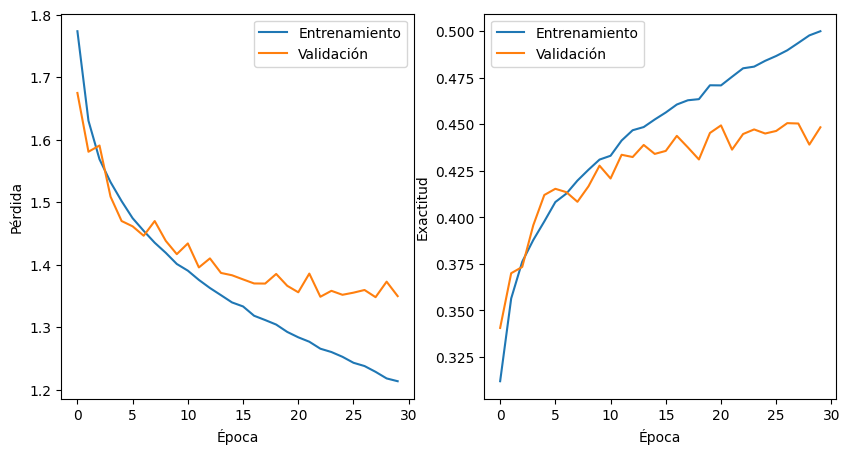

In [49]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(hist['ent']['perdida'], label='Entrenamiento')
axs[0].plot(hist['val']['perdida'], label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(hist['ent']['exactitud'], label='Entrenamiento')
axs[1].plot(hist['val']['exactitud'], label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Exactitud')
axs[1].legend()
plt.show()

In [50]:
pred_val = np.zeros((len(ds_prueba), NUM_CLASSES))
y_val = np.zeros(len(ds_prueba))
with th.no_grad():
  for i in range(len(ds_prueba)):
    x, y = ds_prueba[i]
    x = x.to(DISP)
    pred_val[i] = mejor_modelo(x.unsqueeze(0)).cpu().numpy()
    y_val[i] = y

print(f'F1 = {f1_score(y_val, pred_val.argmax(axis = 1), average = "macro")}\n'
      f'Exactitud = {exactitud(pred_val, y_val)}\n'
      f'Exhaustividad = {recall_score(y_val, pred_val.argmax(axis = 1), average = "macro")}\n'
      f'Precisión = {precision_score(y_val, pred_val.argmax(axis = 1), average = "macro")}\n'
      f'Matriz de confusión:\n {confusion_matrix(y_val, pred_val.argmax(axis = -1))}')

F1 = 0.35059099721132014
Exactitud = 0.431379330220762
Exhaustividad = 0.33488580120624656
Precisión = 0.4475927690137857
Matriz de confusión:
 [[ 201  102    3   31   16    1    4    0    0]
 [ 114 1199  233  430   74   10   17    5    0]
 [   7  251  345  996  175   19   24    3    1]
 [   2   76  195 3544 1100   86  109    4    4]
 [   1   33   61 1966 1403  223  157    6    0]
 [   1   18   26  649  819  324  304    8    0]
 [   2   15    6  217  367  194  397   47    0]
 [   0    8    3   82  107   58  231   63    4]
 [   2    2    2   35   29    8   63   19    8]]


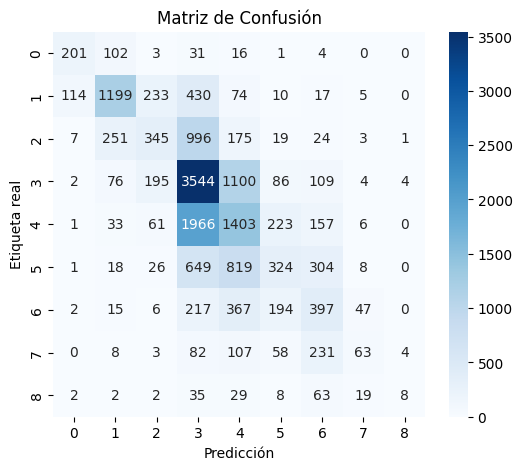

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcula la matriz
cm = confusion_matrix(y_val, pred_val.argmax(axis=1))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión")
plt.show()